In [45]:
import matplotlib.pyplot as plt
from pathlib import Path
import rioxarray
import numpy as np
from rasterio.enums import Resampling
import xarray as xr

In [46]:
current_dir = Path.cwd()
data_dir = current_dir.parent / "data"

copernicus_data = []
for file in (data_dir / "copernicus").glob("*.tif"):
    with rioxarray.open_rasterio(file) as data:
        copernicus_data.append(data.squeeze().drop_vars("band").load())
        break

dataforsyningen_data = []
for file in (data_dir / "dataforsyningen").glob("*.tif"):
    with rioxarray.open_rasterio(file) as data:
        dataforsyningen_data.append(data.squeeze().drop_vars("band").load())
        break

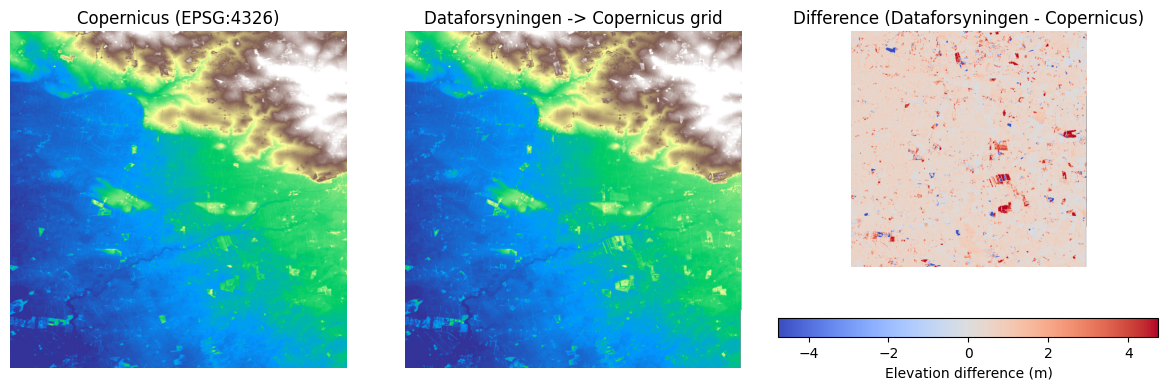

In [47]:
copernicus_first = copernicus_data[0]
dataforsyningen_first = dataforsyningen_data[0]

# Ensure CRS metadata exists
if copernicus_first.rio.crs is None:
    copernicus_first = copernicus_first.rio.write_crs("EPSG:4326")
if dataforsyningen_first.rio.crs is None:
    dataforsyningen_first = dataforsyningen_first.rio.write_crs("EPSG:25832")

# Reproject Dataforsyningen onto the exact Copernicus grid
dataforsyningen_on_copernicus = dataforsyningen_first.rio.reproject_match(
    copernicus_first,
    resampling=Resampling.bilinear,
    nodata=np.nan,
    dtype="float32",
)

# Compare only finite pixels
copernicus_values = copernicus_first.values.astype("float32")
aligned_values = dataforsyningen_on_copernicus.values.astype("float32")
valid = np.isfinite(copernicus_values) & np.isfinite(aligned_values)
difference = aligned_values - copernicus_values

difference_limit = np.nanpercentile(np.abs(difference[valid]), 99)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

elevation_min = np.nanpercentile(copernicus_values[valid], 2)
elevation_max = np.nanpercentile(copernicus_values[valid], 98)

axes[0].imshow(copernicus_values, cmap="terrain", vmin=elevation_min, vmax=elevation_max)
axes[0].set_title("Copernicus (EPSG:4326)")

axes[1].imshow(aligned_values, cmap="terrain", vmin=elevation_min, vmax=elevation_max)
axes[1].set_title("Dataforsyningen -> Copernicus grid")

difference_image = axes[2].imshow(difference, cmap="coolwarm", vmin=-difference_limit, vmax=difference_limit)
axes[2].set_title("Difference (Dataforsyningen - Copernicus)")
fig.colorbar(difference_image, ax=axes[2], label="Elevation difference (m)", orientation="horizontal")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [48]:
copernicus_first.rio.bounds()

(8.999791666666667, 55.000138888888884, 9.213125, 55.142361111111114)

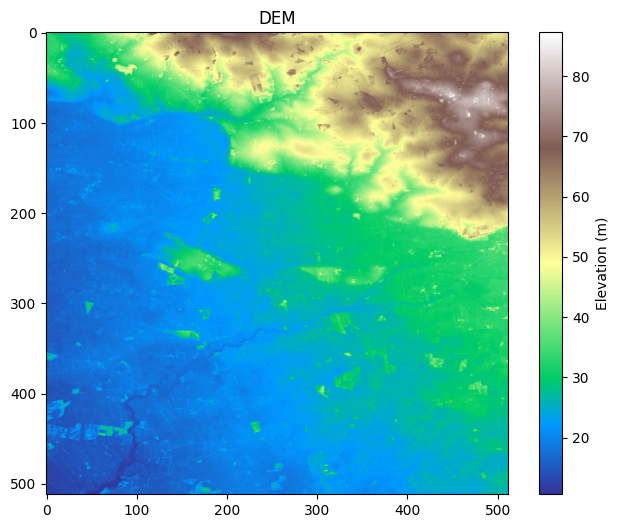

In [49]:
plt.figure(figsize=(8, 6))
plt.imshow(copernicus_first, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("DEM")
plt.show()

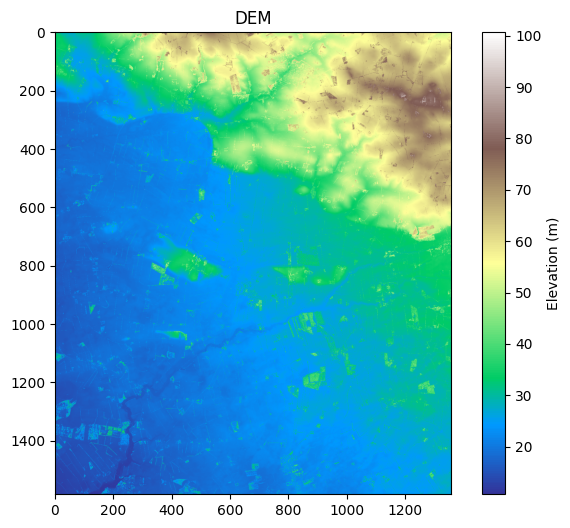

In [50]:
plt.figure(figsize=(8, 6))
plt.imshow(dataforsyningen_first, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("DEM")
plt.show()

In [51]:
dataforsyningen_data[0].rio.bounds()

(499986.67326860793, 6094806.87631153, 513584.96956277295, 6110654.14236988)

In [52]:
# # removing overlaps
# dataforsyningen_clean = []
# for data in dataforsyningen_data:
#     y_overlap = False
#     x_overlap = False
#     for existing in dataforsyningen_clean:
#         data_xmin, data_ymin, data_xmax, data_ymax = data.rio.bounds()
#         existing_xmin, existing_ymin, existing_xmax, existing_ymax = existing.rio.bounds()
#         y_overlap = False
#         x_overlap = False
#         if (data_ymin < existing_ymin and data_ymax > existing_ymin) or\
#             (data_ymin > existing_ymin and data_ymax < existing_ymax) or\
#             (data_ymin < existing_ymax and data_ymax > existing_ymax):
#             y_overlap = True
        
#         if (data_xmin < existing_xmin and data_xmax > existing_xmin) or\
#             (data_xmin > existing_xmin and data_xmax < existing_xmax) or\
#             (data_xmin < existing_xmax and data_xmax > existing_xmax):
#             x_overlap = True

#     if not y_overlap and not x_overlap:
#         dataforsyningen_clean.append(data)
#         print("No overlap detected, adding to clean list")